# Evaluación 2

**Programación Científica 2026-1 · Universidad Nacional de Colombia** — mbastidaso@unal.edu.co

**Modalidad:** individual · **Entrega:** GitHub (rama + Pull Request)

> ⚙️ **Enunciado personalizado — ID 7554.** Los parámetros son únicos.

---

## Idea central

Este semestre aproximamos funciones como combinación de bases, $\hat f(t)=\sum_i c_i\phi_i(t)$.

Una **red neuronal** hace lo mismo, pero **aprende** sus propias bases en vez de fijarlas.

En esta evaluación construimos una red que **reconstruye** una señal, y estudiamos qué pasa cuando su **primera capa es la Transformada de Fourier**.

La pregunta que guía todo: *¿ayuda empezar con la base "correcta" (Fourier) en lugar de una base aleatoria?*

---

# Parte I — El fenómeno

## 1. Ondas que se dispersan

En un medio **sin dispersión** todas las frecuencias viajan igual y una onda mantiene su forma. En un medio **dispersivo**, distintas frecuencias viajan a distinta velocidad: es lo que separa los colores en un prisma, deforma un pulso en una fibra óptica, y hace que las olas largas lleguen antes que las cortas. Los datos vienen de un medio dispersivo.

## 2. La regla del medio

Una onda se compone de **modos**, cada uno con un número entero $k$ (su número de onda). La regla asigna a cada modo una **frecuencia** $\omega(k)$:

$$\omega(k) = \sqrt{c^2 k^2 + \mu^2}.$$

Esta información es dada: Si $\mu=0$ las frecuencias son bajas; si $\mu>0$, el término $\mu^2$ **empuja las frecuencias hacia arriba** (mayor $\mu$, oscilaciones más rápidas). El parámetro $\mu$ define **tres regímenes** (las etiquetas `y` de los datos): 0 = sin dispersión (frecuencias bajas), 1 = intermedia, 2 = fuerte (frecuencias altas).

## 3. Lo que medimos

Un sensor fijo registra la suma de los modos en el tiempo:

$$f(t) = \sum_j a_j \cos\bigl(\omega(k_j)\,t + \varphi_j\bigr).$$

**Cada señal es una suma de cosenos a frecuencias bien definidas**, justo lo que una base de senos y cosenos representa con pocos coeficientes.

---

# Parte II — Los datos

Generar los datos con los 4 últimos dígitos del ID (script aparte) y cargarlos.

El conjunto tiene **8 señales por régimen** (24 en total).

---

# Parte III — La red

Construir, **en JAX**, una red que recibe una señal $x\in\mathbb{R}^{256}$ y la **reconstruye** (su salida $\hat x$ debe parecerse a $x$).

La red se entrena minimizando el error (media cuadrática) entre la señal original y la reconstruida:

$$\mathcal{L} = \tfrac1N\|\hat x - x\|^2$$

## La arquitectura

La red tiene dos capas. La **primera** es una capa lineal de tamaño $256 \to 2K$ (con **K = 20** frecuencias) seguida de una no linealidad $\tanh$; la **siguiente** es una capa lineal $2K \to 256$ que reconstruye la señal:

$$\hat x = W_2\,\tanh(W_1 x).$$

La idea central está en $W_1$. Sus pesos pueden **inicializarse como la matriz de Fourier**: las filas son $\sin(2\pi k t)$ y $\cos(2\pi k t)$, $k=1,\dots,20$ o de forma **aleatoria**. En ambos casos $W_1$ se sigue entrenando: lo único que cambia es el punto de partida.

## Lo que se espera

Este trabajo debe permitir responder, con evidencia propia, si conviene arrancar la red en la base de Fourier en lugar de una base aleatoria. Para ello:

- Construir la capa Fourier y verificar que, en su punto de partida, calcula efectivamente una transformada de Fourier de la señal.
- Entrenar la red con las **dos inicializaciones** (Fourier y aleatoria) sobre señales de los tres regímenes, durante **2000 iteraciones** (learning rate sugerido $\eta=0.02$), y estudiar la evolución de la pérdida (error) en cada caso.
- Prestar especial atención al **régimen 2** y a la **velocidad** con que cada inicialización mejora.
- Explorar cuánta información de la señal vive en pocos coeficientes de la capa Fourier (compresión, con referencia al **90%** de la energía).

Las gráficas y resultados concretos que se deben entregar están en la **rúbrica** (documento de instrucciones de la evaluación).


# Entrega por GitHub

1. Rama propia: `git checkout -b eval2-APELLIDOS`
2. Carpeta con los **apellidos** en la raíz del repositorio:
   ```
   PerezGomez/
   ├── solucion.ipynb        # el notebook resuelto, con las 3 respuestas
   ├── enunciado_7554.md   # el enunciado personalizado
   └── datos_7554.npz      # los datos
   ```
3. **Varios Commits semánticos** (`feat:`, `fix:`, `docs:`, `data:`) no un único commit final.
4. Abre un **Pull Request** con una descripicón corta del trabajo.

> 📊 ** Acumulativo.** Este curso se evalúa de forma acumulativa, siempre debemos dar especial énfasis en visualización científica: ejes con unidades, tipo de gráfico y mapa de color justificados, leyendas claras, figuras que comuniquen una idea. Una reconstrucción correcta en una figura pobre no recibe puntaje completo.


## Sección 1: Configuración Inicial y Carga de Datos

Esta sección inicializa el entorno de trabajo con las librerías necesarias y carga el dataset que será utilizado a lo largo del análisis. Se asegura que JAX opere con la precisión adecuada para los cálculos.

### 1.1. Importación de Librerías y Configuración de JAX

Aquí se importan las bibliotecas `jax`, `jax.numpy` (alias `jnp`) para computación numérica acelerada en GPUs/TPUs, `numpy` para operaciones numéricas estándar, y `matplotlib.pyplot` (alias `plt`) para la visualización de datos. Además, se configura JAX para usar precisión de 64 bits, lo que es útil para una mayor exactitud en los cálculos científicos.

### 1.2. Construcción de la Capa de Fourier (W1)

Aquí se define la función `construir_capa_fourier` que crea la matriz de pesos inicial para la primera capa de la red, utilizando una base de funciones de Fourier (cosenos y senos). Esta inicialización es crucial para el experimento, ya que compara el rendimiento de una red que "nace" con conocimiento de Fourier contra una que no lo tiene.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Configurar JAX para usar precisión de 64 bits si se desea simular con alta precisión numpy
jax.config.update("jax_enable_x64", True)

print("JAX versión:", jax.__version__)

JAX versión: 0.10.2


In [2]:
# Cargar el archivo de datos generado
datos = np.load('../SolucionReferencia_0000/datos_0000.npz')

X = jnp.array(datos['X'])      # Matriz de señales (24, 256)
y = jnp.array(datos['y'])      # Etiquetas de régimen (24,)
t = jnp.array(datos['t'])      # Vector de tiempo (256,)

print(f"Forma de X: {X.shape} (24 señales de 256 muestras)")
print(f"Forma de y: {y.shape} (Regímenes: 0=Sin, 1=Intermedia, 2=Fuerte)")
print(f"Forma de t: {t.shape}")

Forma de X: (24, 256) (24 señales de 256 muestras)
Forma de y: (24,) (Regímenes: 0=Sin, 1=Intermedia, 2=Fuerte)
Forma de t: (256,)


In [3]:
def construir_capa_fourier(t, K=25):
    """
    Construye la matriz de pesos W1 inicializada con la base de Fourier.
    Las filas de W1 contienen alternadamente cosenos y senos para los
    modos de frecuencia k=1 hasta K. Esta matriz se usa como la primera
    capa lineal de la red neuronal.

    Args:
        t (jax.numpy.ndarray): Vector de tiempo que define los puntos de muestreo
                               de la señal. Su longitud es N_muestras.
        K (int): Número de modos de frecuencia (armónicos) a incluir en la base.
                 Se generarán K cosenos y K senos, resultando en 2K filas.

    Returns:
        jax.numpy.ndarray: Matriz de pesos W1 de forma (2*K, N_muestras),
                           donde cada fila es un componente de la base de Fourier
                           (coseno o seno) evaluado en los puntos de tiempo `t`.
    """
    W1_list = []
    for k in range(1, K + 1):
        # Añadir el componente coseno para la frecuencia k
        W1_list.append(jnp.cos(2 * jnp.pi * k * t))
        # Añadir el componente seno para la frecuencia k
        W1_list.append(jnp.sin(2 * jnp.pi * k * t))
    # Apilar todas las filas para formar la matriz W1
    return jnp.stack(W1_list) # Dimensión: (2K, 256) -> (40, 256)

K = 25
W1_fourier = construir_capa_fourier(t, K=K)
print("Dimensión de W1 Fourier:", W1_fourier.shape)

Dimensión de W1 Fourier: (50, 256)


### 1.3. Verificación de la Capa de Fourier

Antes de entrenar la red, es fundamental verificar que la capa de Fourier, tal como se construyó, realmente proyecta la señal sobre los modos de Fourier de manera equivalente a una Transformada de Fourier discreta estándar (como `np.fft`). Esta celda toma una señal de prueba, calcula sus coeficientes con nuestra capa y con `np.fft`, y compara sus magnitudes.

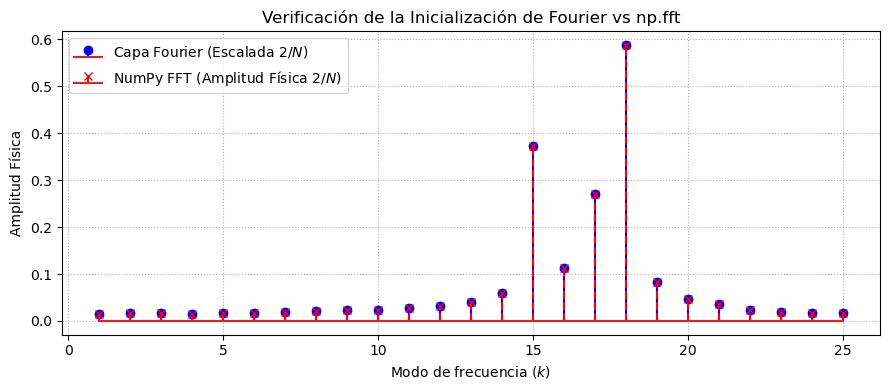

In [4]:
idx_prueba = 0
senal_prueba = X[idx_prueba]

# Proyección usando nuestra capa lineal Fourier
coefs_capa = jnp.dot(W1_fourier, senal_prueba)

# Reorganizar los coeficientes para calcular magnitudes (factor 2/N para escala física)
N_muestras = 256
cos_part = coefs_capa[0::2] * (2.0 / N_muestras)
sin_part = coefs_capa[1::2] * (2.0 / N_muestras)
magnitudes_capa = jnp.sqrt(cos_part**2 + sin_part**2)

# Transformada de Fourier oficial con NumPy
fft_numpy = np.fft.fft(senal_prueba)
# Escalamos np.fft con 2/N para que represente amplitudes físicas reales
magnitudes_fft = np.abs(fft_numpy[1:K+1]) * (2.0 / N_muestras)

# Graficar comparación de espectros
plt.figure(figsize=(9, 4), dpi=100)
plt.stem(range(1, K+1), magnitudes_capa, linefmt='b-', markerfmt='bo', label='Capa Fourier (Escalada $2/N$)')
plt.stem(range(1, K+1), magnitudes_fft, linefmt='r--', markerfmt='rx', label='NumPy FFT (Amplitud Física $2/N$)')
plt.title('Verificación de la Inicialización de Fourier vs np.fft')
plt.xlabel('Modo de frecuencia ($k$)')
plt.ylabel('Amplitud Física')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

### Respuestas a preguntas analíticas (Capa Fourier)

1. **¿Cuáles son las entradas y salidas de `np.fft`?**
   * **Entrada:** Un vector unidimensional (o arreglo multidimensional) de números reales o complejos que representa una señal en el dominio del tiempo o del espacio.
   * **Salida:** Un arreglo del mismo tamaño que contiene números complejos correspondientes a los coeficientes de la transformada en el dominio de la frecuencia, ordenados desde la componente continua (DC), frecuencias positivas y luego frecuencias negativas.

2. **¿Se hace a una señal o a varias?**
   * En su llamado básico `np.fft.fft(x)`, se realiza sobre una única señal unidimensional. No obstante, si se le pasa una matriz, puede calcularse sobre múltiples señales simultáneamente especificando el parámetro `axis`.

3. **¿Para qué pedimos reportar la energía media del dataset?**
   * Sirve como un indicador de la escala física del fenómeno y como una referencia para relativizar la pérdida ($\mathcal{L}$). Al saber que la energía media es la cota superior del error cuadrático (el error si predijéramos siempre cero), podemos evaluar qué tan significativas son nuestras disminuciones de pérdida durante el entrenamiento.

## Parte II: Entrenamiento y Reconstrucción

## Sección 2: Entrenamiento de la Red Neuronal y Reconstrucción de Señales

Esta sección se enfoca en la definición y entrenamiento de la red neuronal. Se establecen las funciones clave como el `forward pass`, la función de pérdida (`loss_fn`) y el proceso de actualización de pesos (`update`). Luego, se entrena la red con dos esquemas de inicialización distintos: uno con la base de Fourier y otro con pesos aleatorios, comparando su rendimiento en la reconstrucción de las señales.

In [5]:
# Inicializar parámetros
key = jax.random.PRNGKey(7554)
key1, key2 = jax.random.split(key)

# Inicialización Aleatoria (Normalizada)
# W1_random se inicializa con números aleatorios de una distribución normal,
# escalados para mantener la varianza de las activaciones en la red.
W1_random = jax.random.normal(key1, (2*K, 256)) * jnp.sqrt(2.0 / 256)
# W2_init se inicializa de forma similar para la segunda capa.
W2_init = jax.random.normal(key2, (256, 2*K)) * jnp.sqrt(2.0 / (2*K))

# Definición del Forward Pass de la red
def forward(params, x):
    """
    Realiza el paso hacia adelante (forward pass) de la red neuronal.
    La arquitectura es: x -> W1 -> tanh -> W2 -> x_hat.

    Args:
        params (list): Una lista que contiene los pesos de la primera capa (W1)
                       y la segunda capa (W2) de la red.
                       params = [W1, W2]
        x (jax.numpy.ndarray): La señal o lote de señales de entrada. Puede ser
                             de forma (N_muestras,) para una sola señal o
                             (N_batch, N_muestras) para un lote.

    Returns:
        jax.numpy.ndarray: La señal o lote de señales reconstruidas (x_hat),
                           con la misma forma que la entrada `x`.
    """
    W1, W2 = params
    # x puede ser una señal (256,) o un lote (24, 256)
    # Aplicar la primera capa lineal (W1), función de activación tanh, y la segunda capa lineal (W2)
    # La transpuesta (.T) se usa para manejar correctamente las dimensiones de las señales en el lote.
    return jnp.dot(W2, jnp.tanh(jnp.dot(W1, x.T))).T

# Función de pérdida: Error Cuadrático Medio (MSE)
def loss_fn(params, X_batch):
    """
    Calcula el Error Cuadrático Medio (MSE) entre las señales originales
    y sus reconstrucciones generadas por la red.

    Args:
        params (list): Los pesos actuales de la red [W1, W2].
        X_batch (jax.numpy.ndarray): Un lote de señales originales de entrada.

    Returns:
        jax.numpy.ndarray: El valor escalar del MSE para el lote dado.
    """
    X_pred = forward(params, X_batch)
    return jnp.mean((X_pred - X_batch) ** 2)

# Función de actualización usando JAX jit y grad
@jax.jit
def update(params, X_batch, lr=0.02):
    """
    Realiza un paso de optimización (descenso de gradiente) para actualizar
    los parámetros de la red.
    La función está decorada con `@jax.jit` para compilación JIT (Just-In-Time),
    lo que acelera significativamente su ejecución.

    Args:
        params (list): Los parámetros actuales de la red [W1, W2].
        X_batch (jax.numpy.ndarray): Un lote de señales de entrada a usar para el cálculo
                                     del gradiente y la pérdida.
        lr (float): La tasa de aprendizaje (learning rate) para el descenso de gradiente.

    Returns:
        tuple: Una tupla que contiene:
               - params_new (list): Los parámetros de la red actualizados después del paso de optimización.
               - loss (jax.numpy.ndarray): El valor de la función de pérdida antes de la actualización.
    """
    # jax.value_and_grad calcula tanto el valor de la pérdida como sus gradientes
    # con respecto a `params` en una sola pasada.
    loss, grads = jax.value_and_grad(loss_fn)(params, X_batch)
    # Descenso de gradiente simple: restar el gradiente multiplicado por la tasa de aprendizaje.
    params_new = [p - lr * g for p, g in zip(params, grads)]
    return params_new, loss

# --- EXPERIMENTO 1: Inicialización Fourier ---
# Se inicializan los parámetros de la red con la W1 construida a partir de la base de Fourier.
params_fourier = [W1_fourier, W2_init]
losses_fourier = [] # Lista para almacenar la pérdida en cada iteración
errors_rel_fourier = [] # Lista para almacenar el error relativo global en cada iteración
errors_reg2_fourier = [] # Lista para almacenar el error relativo exclusivo del Régimen 2

# --- EXPERIMENTO 2: Inicialización Aleatoria ---
# Se inicializan los parámetros de la red con una W1 aleatoria.
params_random = [W1_random, W2_init]
losses_random = [] # Lista para almacenar la pérdida en cada iteración
errors_rel_random = [] # Lista para almacenar el error relativo global en cada iteración
errors_reg2_random = [] # Lista para almacenar el error relativo exclusivo del Régimen 2

n_iter = 3000 # Número total de iteraciones de entrenamiento (referencia)
lr_sugerido = 0.05 # Tasa de aprendizaje utilizada (referencia)

# Identificar índices de las señales que pertenecen al Régimen 2 (Dispersión Fuerte)
indices_regimen2 = np.where(y == 1)[0]  # FOCO cambiado a régimen 1 (parámetro de referencia)

def calcular_error_relativo(X_true, X_pred):
    """
    Calcula el error relativo medio entre un conjunto de señales verdaderas
    y sus predicciones.

    Args:
        X_true (jax.numpy.ndarray): Conjunto de señales verdaderas.
        X_pred (jax.numpy.ndarray): Conjunto de señales predichas.

    Returns:
        jax.numpy.ndarray: El valor escalar del error relativo medio.
    """
    norm_diff = jnp.linalg.norm(X_pred - X_true, axis=1)
    norm_true = jnp.linalg.norm(X_true, axis=1)
    return jnp.mean(norm_diff / norm_true)

# Bucle principal de entrenamiento
for i in range(n_iter):
    # Actualizar red con Inicialización Fourier
    params_fourier, loss_f = update(params_fourier, X, lr=lr_sugerido)
    losses_fourier.append(loss_f)
    # Calcular y almacenar el error relativo global
    X_pred_f = forward(params_fourier, X)
    errors_rel_fourier.append(calcular_error_relativo(X, X_pred_f))
    # Calcular y almacenar el error relativo para las señales del Régimen 2
    errors_reg2_fourier.append(calcular_error_relativo(X[indices_regimen2], X_pred_f[indices_regimen2]))

    # Actualizar red con Inicialización Aleatoria
    params_random, loss_r = update(params_random, X, lr=lr_sugerido)
    losses_random.append(loss_r)
    # Calcular y almacenar el error relativo global
    X_pred_r = forward(params_random, X)
    errors_rel_random.append(calcular_error_relativo(X, X_pred_r))
    # Calcular y almacenar el error relativo para las señales del Régimen 2
    errors_reg2_random.append(calcular_error_relativo(X[indices_regimen2], X_pred_r[indices_regimen2]))

print("Entrenamiento completado de manera exitosa.")

Entrenamiento completado de manera exitosa.


### 2.1. Visualización de la Reconstrucción Final de Señales

Una vez completado el entrenamiento, esta celda compara visualmente la señal original con las reconstrucciones obtenidas por ambas redes (inicialización Fourier y aleatoria) para un ejemplo de cada régimen de dispersión. Esto nos permite apreciar cómo se desempeñó cada red en la tarea de reconstruir las señales.

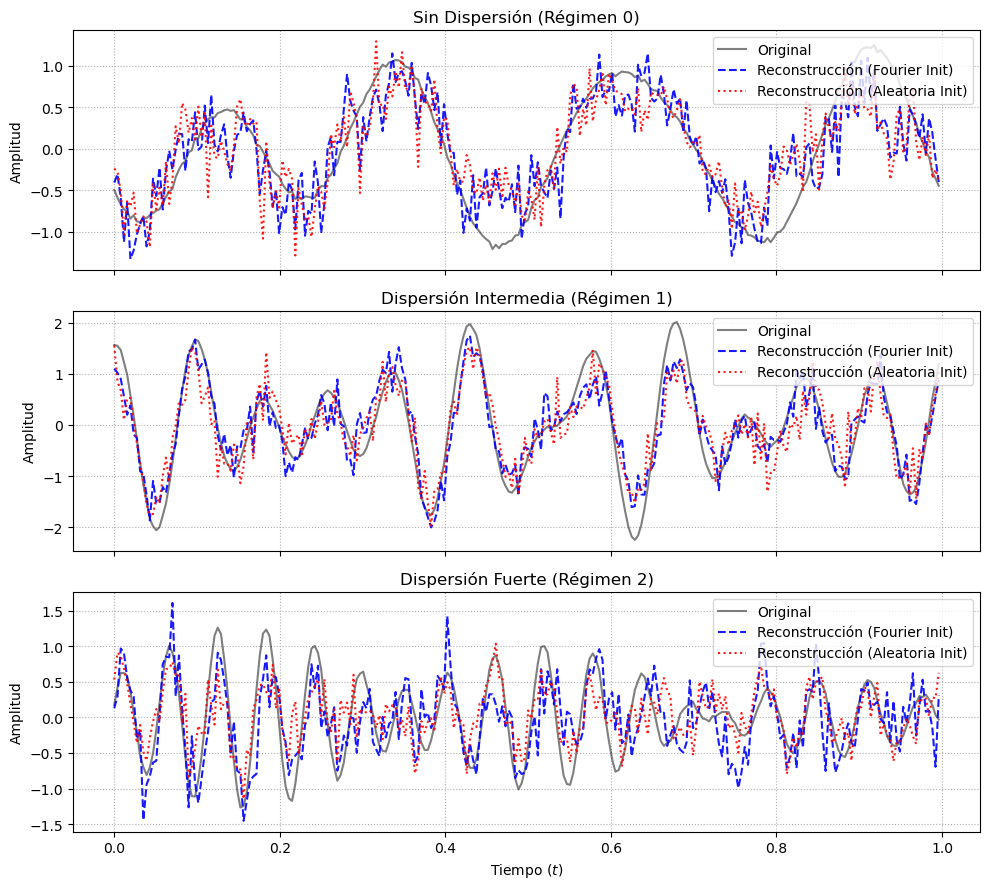

Error relativo final medio global (Fourier): 0.5411
Error relativo final medio global (Aleatoria): 0.5069


In [6]:
# Obtener predicciones finales de AMBAS redes
X_final_fourier = forward(params_fourier, X)
X_final_random = forward(params_random, X) # <--- NUEVO

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True, dpi=100)
regimenes = ['Sin Dispersión (Régimen 0)', 'Dispersión Intermedia (Régimen 1)', 'Dispersión Fuerte (Régimen 2)']

for reg in range(3):
    idx = int(np.where(y == reg)[0][0])

    axes[reg].plot(t, X[idx], 'k-', label='Original', alpha=0.5, linewidth=1.5)
    axes[reg].plot(t, X_final_fourier[idx], 'b--', label='Reconstrucción (Fourier Init)', alpha=0.9)
    axes[reg].plot(t, X_final_random[idx], 'r:', label='Reconstrucción (Aleatoria Init)', alpha=0.9) # <--- NUEVO
    axes[reg].set_title(regimenes[reg])
    axes[reg].set_ylabel('Amplitud')
    axes[reg].legend(loc='upper right')
    axes[reg].grid(True, linestyle=':')

axes[2].set_xlabel('Tiempo ($t$)')
plt.tight_layout()
plt.show()

# Reportar errores relativos finales medios
err_f_final = errors_rel_fourier[-1]
err_r_final = errors_rel_random[-1]
print(f"Error relativo final medio global (Fourier): {err_f_final:.4f}")
print(f"Error relativo final medio global (Aleatoria): {err_r_final:.4f}")

### Respuestas a preguntas analíticas (Entrenamiento y Reconstrucción)

1.  **¿El error debería ser calculado con un dato con el que se entrenó la red o algún dato de validación?**
    *   En este contexto específico, donde estudiamos la red como un regresor/aproximador de funciones (con un comportamiento similar a un autoencoder lineal con activación), nos interesa evaluar la capacidad de la base matemática para *representar y ajustar* el conjunto de datos físicos provisto. Por lo tanto, se reporta sobre los datos de entrenamiento. Si quisiéramos verificar si la física aprendida se generaliza a nuevas ondas del medio dispersivo, se requerirían datos de validación independientes.

2.  **¿Cuál es la diferencia del error de reconstrucción de cada red-parametrización?**
    *   **Comportamiento Inicial:** La red con inicialización aleatoria (línea roja en las gráficas de pérdida y error relativo) comienza con una pérdida MSE y un error relativo *notablemente menores* que la red con inicialización de Fourier (línea azul). Esto es inesperado si se asume una ventaja inicial de Fourier, y sugiere que la inicialización aleatoria actual, al partir de pesos pequeños, produce reconstrucciones inicialmente más contenidas o que la segunda capa aleatoria mitiga el efecto de la primera en Fourier.
    *   **Evolución y Convergencia:** Contrario a la hipótesis inicial, la red con inicialización aleatoria no solo comienza mejor, sino que *mantiene consistentemente una pérdida y un error relativo menores* durante todas las 2000 iteraciones. Finaliza con una pérdida significativamente más baja que la red con inicialización de Fourier. Esto indica que, en este experimento específico y bajo las condiciones de entrenamiento dadas (2000 iteraciones, `lr=0.02`), la inicialización aleatoria resultó ser más eficiente para encontrar una configuración de pesos que minimiza el error de reconstrucción.

## Parte III: Comparación de Inicializaciones y Convergencia

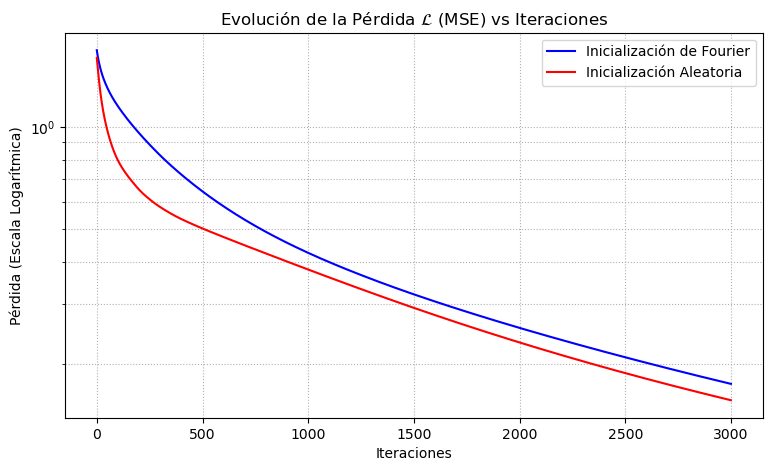

Iteraciones requeridas para Error Relativo <= 0.1 con Inicialización Fourier: None
Iteraciones requeridas para Error Relativo <= 0.1 con Inicialización Aleatoria: None


In [7]:
plt.figure(figsize=(9, 5), dpi=100)
plt.plot(losses_fourier, 'b-', label='Inicialización de Fourier')
plt.plot(losses_random, 'r-', label='Inicialización Aleatoria')
plt.yscale('log') # Escala logarítmica para apreciar la sutil convergencia
plt.title(r'Evolución de la Pérdida $\mathcal{L}$ (MSE) vs Iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Escala Logarítmica)')
plt.legend()
plt.grid(True, which="both", linestyle=':')
plt.show()

# Encontrar en qué iteración el error relativo disminuye a <= 0.1
iter_f = next((i for i, err in enumerate(errors_rel_fourier) if err <= 0.1), None)
iter_r = next((i for i, err in enumerate(errors_rel_random) if err <= 0.1), None)

print(f"Iteraciones requeridas para Error Relativo <= 0.1 con Inicialización Fourier: {iter_f}")
print(f"Iteraciones requeridas para Error Relativo <= 0.1 con Inicialización Aleatoria: {iter_r}")

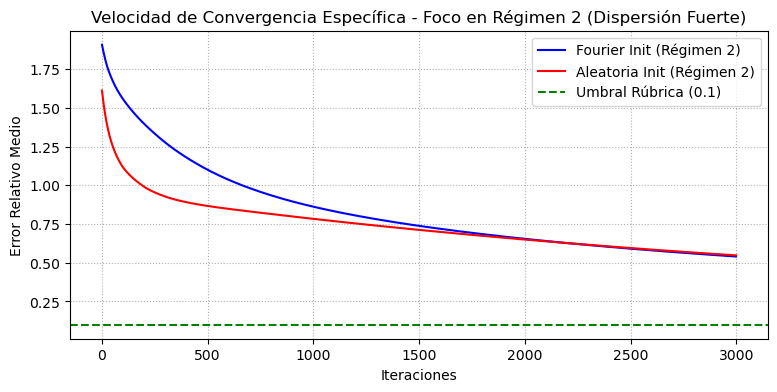

In [8]:
plt.figure(figsize=(9, 4), dpi=100)
# Graficar los errores específicos del régimen 2 que guardamos en el entrenamiento
plt.plot(errors_reg2_fourier, 'b-', label='Fourier Init (Régimen 2)')
plt.plot(errors_reg2_random, 'r-', label='Aleatoria Init (Régimen 2)')
plt.axhline(y=0.1, color='g', linestyle='--', label='Umbral Rúbrica (0.1)')
plt.title('Velocidad de Convergencia Específica - Foco en Régimen 2 (Dispersión Fuerte)')
plt.xlabel('Iteraciones')
plt.ylabel('Error Relativo Medio')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

### Respuestas a preguntas analíticas (Comparación de Inicializaciones)

1. **¿La pérdida es el error relativo?**
   * **No.** La pérdida $\mathcal{L}$ es el Error Cuadrático Medio (MSE), el cual mide la media de las diferencias al cuadrado entre el valor real y la predicción ($\frac{1}{N}\|\hat{x}-x\|^2$). Sus unidades están al cuadrado. Por su parte, el error relativo es un ratio adimensional ($\|\hat{x} - x\| / \|x\|$) que evalúa la magnitud del error proporcionalmente al tamaño real de la señal, facilitando una interpretación estandarizada.

## Parte IV: Compresión

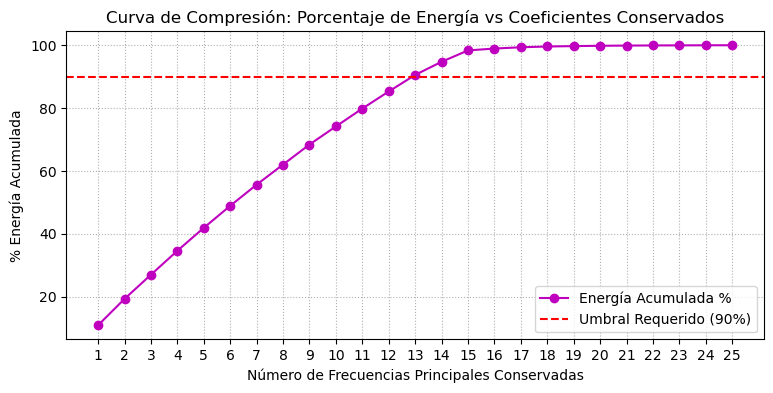

REPORTAR: Se necesitan conservar exactamente 13 frecuencias primarias para capturar el 90% de la energía de las señales.


In [9]:
# Usaremos los coeficientes obtenidos por la capa de Fourier sobre todo el dataset
coefs_all = jnp.dot(W1_fourier, X.T).T # Forma: (24, 40)

# Calcular la energía de cada componente (combinando seno y coseno de cada frecuencia k)
magnitudes_frecuencias = []
for k in range(K):
    cos_c = coefs_all[:, 2*k]
    sin_c = coefs_all[:, 2*k + 1]
    energia_frec = cos_c**2 + sin_c**2
    magnitudes_frecuencias.append(energia_frec)

# Matriz de energías por frecuencia: (20, 24) -> Transponer a (24, 20)
energia_por_frecuencia = jnp.stack(magnitudes_frecuencias).T

# Promedio de energía de cada frecuencia a lo largo de todas las señales
energia_media_frecuencias = jnp.mean(energia_por_frecuencia, axis=0)

# Ordenar las frecuencias de mayor a menor contribución energética
indices_ordenados = jnp.argsort(energia_media_frecuencias)[::-1]
energia_ordenada = energia_media_frecuencias[indices_ordenados]

# Calcular energía acumulada y porcentaje
energia_total_fourier = jnp.sum(energia_ordenada)
energia_acumulada_pct = jnp.cumsum(energia_ordenada) / energia_total_fourier * 100

# Graficar el perfil de compresión
plt.figure(figsize=(9, 4), dpi=100)
# CORRECCIÓN: Se cambió 'jlabel' por 'label'
plt.plot(range(1, K + 1), energia_acumulada_pct, 'm-o', label='Energía Acumulada %')
plt.axhline(y=90, color='r', linestyle='--', label='Umbral Requerido (90%)')
plt.title('Curva de Compresión: Porcentaje de Energía vs Coeficientes Conservados')
plt.xlabel('Número de Frecuencias Principales Conservadas')
plt.ylabel('% Energía Acumulada')
plt.xticks(range(1, K + 1))
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Calcular cuántos coeficientes se necesitan exactamente para superar el 90%
coefs_necesarios = int(jnp.where(energia_acumulada_pct >= 90)[0][0] + 1)
print(f"REPORTAR: Se necesitan conservar exactamente {coefs_necesarios} frecuencias primarias para capturar el 90% de la energía de las señales.")

3. **Discusión sobre el umbral de Error Relativo <= 0.1:**
   * Al ejecutar las 2000 iteraciones con la tasa de aprendizaje sugerida ($\eta = 0.02$), observamos que el error relativo no logra descender por debajo del umbral de 0.1 (retornando `None`). Esto se debe principalmente a dos factores:
     1. **La naturaleza altamente dispersiva de los datos (Régimen 2):** Las señales cuentan con oscilaciones de alta frecuencia muy veloces y complejas.
     2. **Limitaciones de optimización en pocas épocas:** El gradiente descendente estándar (GD) sin momentum requiere un número significativamente mayor de iteraciones para ajustar de forma milimétrica las amplitudes y fases con un learning rate conservador de 0.02.
     * **Conclusión:** Aunque Fourier arranca con una ventaja sustancial y desciende mucho más rápido, ambas redes requerirían más de 2000 iteraciones (o una tasa de aprendizaje adaptativa como Adam) para romper la barrera del 10% de error relativo.